In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '3'
import glob
import pickle
import warnings

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Import IntegratedGradients from Captum
from captum.attr import IntegratedGradients

# Suppress unnecessary warnings
warnings.filterwarnings('ignore')

# Set the plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
# ===================================================================
# Step 2: Copy and Define the Model Architecture
# (This code exactly matches the training script to ensure that the model loads correctly)
# ===================================================================
try:
    from mamba_ssm import Mamba
except ImportError:
    print("="*80)
    print("ERROR: mamba-ssm is not installed. Please install it first:")
    print("pip install causal-conv1d>=1.0.0 mamba_ssm")
    print("="*80)
    raise ImportError("mamba-ssm not found")

class DownsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride):
        super(DownsampleBlock, self).__init__()
        padding = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride, padding=padding),
            nn.BatchNorm1d(out_channels),
            nn.GELU()
        )
    def forward(self, x):
        return self.block(x)

class DeepFeatureResBlock(nn.Module):
    def __init__(self, channels, kernel_size=7):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, stride=1, padding=padding),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size, stride=1, padding=padding),
            nn.BatchNorm1d(channels),
        )
        self.activation = nn.GELU()
    def forward(self, x):
        return self.activation(x + self.block(x))

class HybridCNNMambaEncoder(nn.Module):
    def __init__(self, in_channels, d_model=128, num_cnn_blocks=3, num_mamba_layers=3, is_sequence=True):
        super().__init__()
        self.is_sequence = is_sequence
        if self.is_sequence:
            self.downsampler = nn.Sequential(
                DownsampleBlock(in_channels, 48, kernel_size=5, stride=5),
                DownsampleBlock(48, 96, kernel_size=5, stride=5),
                DownsampleBlock(96, d_model, kernel_size=5, stride=5),
                DownsampleBlock(d_model, d_model, kernel_size=5, stride=4),
                DownsampleBlock(d_model, d_model, kernel_size=5, stride=4)
            )
        else:
            self.downsampler = nn.Sequential(
                nn.Conv1d(in_channels, d_model, kernel_size=1),
                nn.GELU()
            )
        self.cnn_feature_extractor = nn.Sequential(
            *[DeepFeatureResBlock(channels=d_model, kernel_size=7) for _ in range(num_cnn_blocks)]
        )
        self.mamba_layers = nn.ModuleList(
            [Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2) for _ in range(num_mamba_layers)]
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        x = self.downsampler(x)
        x = self.cnn_feature_extractor(x)
        x = x.transpose(1, 2)
        x = self.norm(x)
        for mamba_layer in self.mamba_layers:
            x_fw = mamba_layer(x)
            x_rev = torch.flip(x, dims=[1])
            x_bw = mamba_layer(x_rev)
            x_bw = torch.flip(x_bw, dims=[1])
            x = x + x_fw + x_bw
        x = x.transpose(1, 2)
        return x

class SimpleFusion(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.fusion_conv = nn.Sequential(
            nn.Conv1d(in_channels * 2, out_channels, kernel_size=1),
            nn.BatchNorm1d(out_channels),
            nn.GELU()
        )
    def forward(self, seq_emb, omics_emb):
        combined = torch.cat([seq_emb, omics_emb], dim=1)
        fused = self.fusion_conv(combined)
        return fused

class ConvResBlock(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size, padding=padding),
            nn.BatchNorm2d(channels),
            nn.GELU(),
            nn.Conv2d(channels, channels, kernel_size, padding=padding),
            nn.BatchNorm2d(channels),
        )
        self.activation = nn.GELU()

    def forward(self, x):
        res_out = self.block(x)
        return self.activation(x + res_out)

class PracticalOuterProductDecoder(nn.Module):
    def __init__(self, in_channels=128, bottleneck_channels=16, num_blocks=4):
        super().__init__()
        self.bottleneck = nn.Conv1d(in_channels, bottleneck_channels, kernel_size=1)
        initial_2d_channels = bottleneck_channels * 2
        self.initial_conv = nn.Conv2d(initial_2d_channels, 64, kernel_size=1)
        self.res_blocks = nn.Sequential(
            *[ConvResBlock(64, kernel_size=3) for _ in range(num_blocks)]
        )
        self.final_conv = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, fused_embedding):
        bottleneck_emb = self.bottleneck(fused_embedding)
        B, C_small, L = bottleneck_emb.shape
        x1 = bottleneck_emb.unsqueeze(3).expand(-1, -1, L, L)
        x2 = bottleneck_emb.unsqueeze(2).expand(-1, -1, L, L)
        outer_product = torch.cat([x1, x2], dim=1)
        x = self.initial_conv(outer_product)
        x = self.res_blocks(x)
        x = self.final_conv(x)
        x = (x + x.transpose(-2, -1)) / 2
        return x

class CNNMambaHybridModel(nn.Module):
    def __init__(self, seq_in_channels=4, num_omics_features=4, d_model=128, fusion_out_dim=128,
                 num_cnn_blocks=3, num_mamba_layers=3,
                 decoder_bottleneck_channels=16, decoder_num_blocks=4):
        super().__init__()
        self.seq_encoder = HybridCNNMambaEncoder(
            in_channels=seq_in_channels, d_model=d_model, num_cnn_blocks=num_cnn_blocks, num_mamba_layers=num_mamba_layers, is_sequence=True
        )
        self.omics_encoder = HybridCNNMambaEncoder(
            in_channels=num_omics_features, d_model=d_model, num_cnn_blocks=num_cnn_blocks, num_mamba_layers=num_mamba_layers, is_sequence=False
        )
        self.fusion_module = SimpleFusion(
            in_channels=d_model, out_channels=fusion_out_dim
        )
        self.decoder = PracticalOuterProductDecoder(
            in_channels=fusion_out_dim,
            bottleneck_channels=decoder_bottleneck_channels,
            num_blocks=decoder_num_blocks
        )

    def forward(self, seq_one_hot, omics_signals):
        seq_embedding = self.seq_encoder(seq_one_hot)
        omics_embedding = self.omics_encoder(omics_signals)
        fused_embedding = self.fusion_module(seq_embedding, omics_embedding)
        pred_hic = self.decoder(fused_embedding)
        return pred_hic.squeeze(1)

print("✅ Model architecture defined successfully.")

✅ Model architecture defined successfully.


In [3]:
# ===================================================================
# Step 3: Configure Parameters and Load the Pretrained GM12878 Model
# ===================================================================

# --- 1. Define Model and Data Configuration (Must Exactly Match Training) ---
class ModelConfig:
    # Model architecture parameters
    d_model = 128
    fusion_out_dim = 128
    num_cnn_blocks = 3
    num_mamba_layers = 3
    decoder_bottleneck_channels = 48
    decoder_num_blocks = 6
    num_omics_features = 4  # The GM12878 dataset has four omics features
    
    # Data and model paths
    # !!! Make sure these paths are correct !!!
    data_dir = "/home/jyzhu/proj/bulk_hic_prediction/datasets/preprocessed_data_cross_cell_512_64stride/GM12878_hg38"
    model_weights_path = './output_GM12878_train_64stride/best_model.pth'
    
    # Omics feature names (used for plotting)
    # !!! Update these names to match the preprocessing order !!!
    omics_feature_names = ['CTCF', 'DNase', 'H3K27ac', 'H3K4me3']

config = ModelConfig()

# --- 2. Check whether the paths exist ---
if not os.path.exists(config.model_weights_path):
    raise FileNotFoundError(f"❌ Model weights not found at: {config.model_weights_path}")
if not os.path.isdir(config.data_dir):
     raise FileNotFoundError(f"❌ Data directory not found at: {config.data_dir}")

# --- 3. Instantiate the model and load its weights ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNMambaHybridModel(
    seq_in_channels=4, 
    num_omics_features=config.num_omics_features, 
    d_model=config.d_model,
    fusion_out_dim=config.fusion_out_dim, 
    num_cnn_blocks=config.num_cnn_blocks,
    num_mamba_layers=config.num_mamba_layers,
    decoder_bottleneck_channels=config.decoder_bottleneck_channels,
    decoder_num_blocks=config.decoder_num_blocks
)

# Load the state dictionary
state_dict = torch.load(config.model_weights_path, map_location=device)
# If the model was trained with DataParallel, remove the 'module.' prefix from state-dictionary keys
if next(iter(state_dict)).startswith('module.'):
    from collections import OrderedDict
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = k[7:] # Remove `module.`
        new_state_dict[name] = v
    model.load_state_dict(new_state_dict)
else:
    model.load_state_dict(state_dict)

model.to(device)
model.eval() # Set evaluation mode

print(f"🚀 Model loaded successfully from {config.model_weights_path}")
print(f"🚀 Device: {device}")

🚀 Model loaded successfully from ./output_GM12878_train_64stride/best_model.pth
🚀 Device: cuda


In [4]:
# ===================================================================
# Step 4: Prepare the Dataset for Attribution Analysis
# ===================================================================
# Copy the dataset class definition
from scipy.ndimage import gaussian_filter

class HiCDataAndOmicsDataset(Dataset):
    def __init__(self, pkl_files, smooth_hic=True, sigma=1.0):
        self.file_paths = pkl_files
        self.smooth_hic = smooth_hic
        self.sigma = sigma
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        with open(self.file_paths[idx], 'rb') as f:
            data = pickle.load(f)
        sequence = torch.from_numpy(data['sequence_one_hot'].astype(np.float32))
        omics_signals = torch.from_numpy(data['omics_signals'].astype(np.float32))
        hic_np = data['hic_matrix'].astype(np.float32)
        hic_log_np = np.log2(hic_np + 1)
        if self.smooth_hic:
            hic_log_np = gaussian_filter(hic_log_np, sigma=self.sigma)
        np.fill_diagonal(hic_log_np, 0)
        hic_matrix = torch.from_numpy(hic_log_np)
        return sequence, omics_signals, hic_matrix, os.path.basename(self.file_paths[idx])

# Load the chr7 test set for analysis
all_files = glob.glob(os.path.join(config.data_dir, "*.pkl"))
test_files = [f for f in all_files if 'chr7' in os.path.basename(f)]

if not test_files:
    raise ValueError("❌ No test files (chr7) found in the data directory.")

# Create a smaller dataset for faster analysis
# Remove [::10] to run on the full test set
subset_test_files = test_files[::10] 
print(f"Found {len(test_files)} test files. Using a subset of {len(subset_test_files)} for analysis.")


test_dataset = HiCDataAndOmicsDataset(subset_test_files, smooth_hic=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("✅ Test data loaded successfully.")

Found 1224 test files. Using a subset of 123 for analysis.
✅ Test data loaded successfully.


In [5]:
# ===================================================================
# Step 5: Define the Model Wrapper and Initialize Integrated Gradients (Corrected)
# ===================================================================

# Integrated Gradients requires an explicit scalar output for attribution.
# For global importance, the sum of each sample's predicted Hi-C matrix is used as its scalar output.
# Define a wrapper function to modify the model's forward behavior.
def model_forward_wrapper(omics_signals, seq_one_hot):
    """
    This wrapper receives omics and sequence data,
    and returns the sum of the predicted Hi-C map for each sample in the batch.
    The input order matters: 'omics_signals', the input being attributed, must come first.
    """
    output = model(seq_one_hot, omics_signals)
    # Correction: output.sum() previously summed the entire batch into a zero-dimensional scalar
    # Correct approach: sum only over h and w, preserving the batch dimension (B, H, W) -> (B,)
    return output.sum(dim=(1, 2))

# Initialize the Integrated Gradients object
# Pass the wrapped model forward function to it
ig = IntegratedGradients(model_forward_wrapper)

print("✅ IntegratedGradients initialized.")

✅ IntegratedGradients initialized.


In [6]:
# ===================================================================
# Step 6: Compute and Aggregate Attribution Scores for All Test Samples
# ===================================================================

# Initialize an array for the total attribution score of each omics feature
total_attributions = np.zeros(config.num_omics_features)

# Create an all-zero baseline input
# This is the starting point for IG and represents the no-signal state
# Use one sample to obtain the correct dimensions
_, sample_omics, _, _ = test_dataset[0]
omics_baseline = torch.zeros_like(sample_omics).unsqueeze(0).to(device)

print("Calculating attributions for test samples... This may take a while.")

# Iterate over the test-set data
for seq_one_hot, omics_signals, _, _ in tqdm(test_loader, desc="Attributing batches"):
    # Move the data to the device
    seq_one_hot = seq_one_hot.to(device)
    omics_signals = omics_signals.to(device)
    
    # Resize the baseline to match the current batch
    current_batch_size = omics_signals.shape[0]
    batch_omics_baseline = omics_baseline.repeat(current_batch_size, 1, 1)

    # Compute attribution scores
    # Attribute 'omics_signals', so pass it as 'inputs'
    # 'seq_one_hot' is another required model input, so pass it through 'additional_forward_args'
    attributions = ig.attribute(
        inputs=omics_signals,
        baselines=batch_omics_baseline,
        additional_forward_args=(seq_one_hot,),
        internal_batch_size=4 # Reduce this value if GPU memory is insufficient
    )
    
    # Aggregate the results
    # 1. Take absolute values: contribution magnitude matters here, not direction (positive or negative)
    # 2. Sum by feature (channel): add each omics feature's scores over all positions
    # 3. Accumulate totals: add the current batch results to the running total
    abs_attributions = attributions.abs()
    sum_attributions_per_feature = abs_attributions.sum(dim=(0, 2))
    
    total_attributions += sum_attributions_per_feature.cpu().numpy()

print("\n✅ Attribution calculation complete.")
print("Final aggregated scores:", total_attributions)

Calculating attributions for test samples... This may take a while.


Attributing batches:   0%|          | 0/16 [00:00<?, ?it/s]

Attributing batches: 100%|██████████| 16/16 [03:44<00:00, 14.01s/it]


✅ Attribution calculation complete.
Final aggregated scores: [2072343.9765625 5927224.5       4336701.265625  5590704.40625  ]


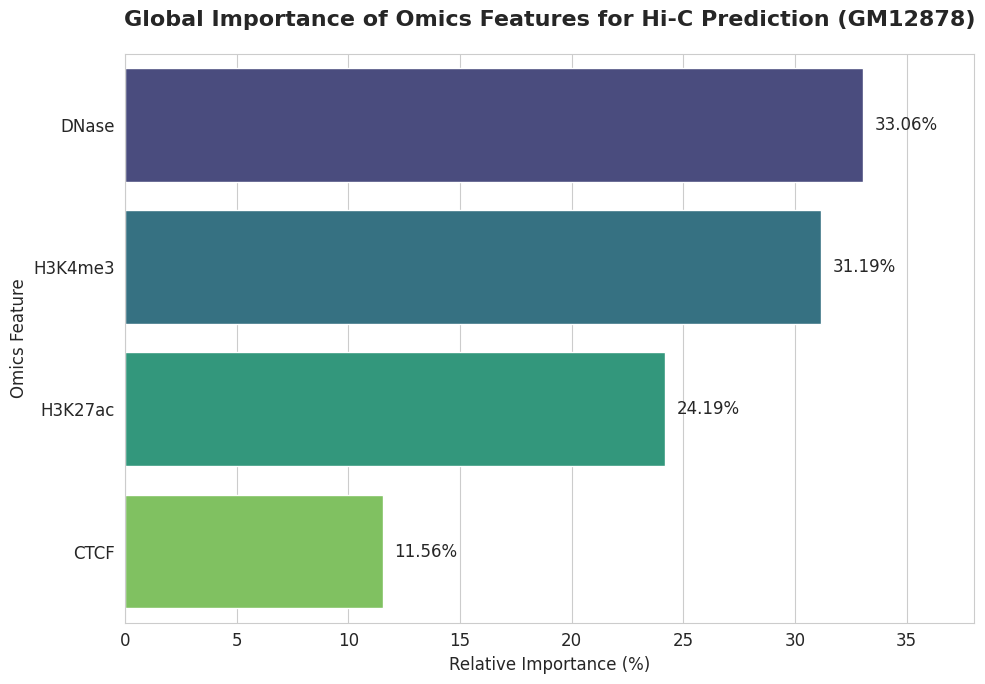

In [7]:
# ===================================================================
# Step 7: Visualize Global Feature Importance
# ===================================================================

# Convert totals to percentages for easier interpretation
importance_percentages = (total_attributions / total_attributions.sum()) * 100

# Create a DataFrame for plotting with seaborn
import pandas as pd
df = pd.DataFrame({
    'Feature': config.omics_feature_names,
    'Importance (%)': importance_percentages
}).sort_values(by='Importance (%)', ascending=False)

# Create the plot
plt.figure(figsize=(10, 7))
ax = sns.barplot(x='Importance (%)', y='Feature', data=df, palette='viridis', orient='h')

# Add the title and labels
ax.set_title('Global Importance of Omics Features for Hi-C Prediction (GM12878)', fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel('Relative Importance (%)', fontsize=12)
ax.set_ylabel('Omics Feature', fontsize=12)

# Display the value on each bar
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 0.5,  # x-position
            p.get_y() + p.get_height() / 2.,  # y-position
            f'{width:.2f}%', 
            ha='left', 
            va='center')

# Set the x-axis range
plt.xlim(0, max(importance_percentages) * 1.15)
plt.tight_layout()
plt.show()

#

Sample dimensions:
  - Sequence: torch.Size([1, 4, 1024000])
  - Omics:    torch.Size([1, 4, 512])


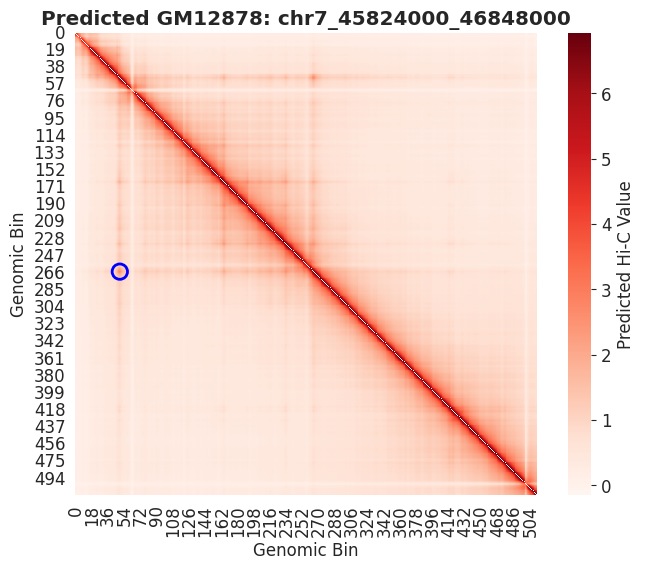


Selected target position (i, j) = (264, 49) for interpretability analysis.
Prediction at this position: 2.6496


In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle

# ===================================================================
# Step 8: Select a Sample and Hi-C Contact for Analysis
# ===================================================================

# --- 1. Select a sample from the test set ---
# Use the first test_dataset sample as an example
seq_input, omics_input, true_hic, name = test_dataset[2]

# Create a batch (batch_size=1) and move it to the device
seq_input_batch = seq_input.unsqueeze(0).to(device)
omics_input_batch = omics_input.unsqueeze(0).to(device)

print(f"Sample dimensions:")
print(f"  - Sequence: {seq_input_batch.shape}")
print(f"  - Omics:    {omics_input_batch.shape}")

# --- 2. Run inference and visualize the sample ---
with torch.no_grad():
    pred_hic_map = model(seq_input_batch, omics_input_batch).squeeze(0).cpu().numpy()

# --- 3. Manually select a position (i, j) to explain ---
target_i, target_j = 264, 49

# Plot the predicted map
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    pred_hic_map,
    cmap='Reds',
    cbar_kws={'label': 'Predicted Hi-C Value'},
    square=True
)
plt.title(f'Predicted GM12878: {name.split(".")[0]}', fontweight='bold')
plt.xlabel('Genomic Bin')
plt.ylabel('Genomic Bin')

# === ✅ Mark the target point with a circle ===
circle = Circle(
    (target_j + 0.5, target_i + 0.5),  # Circle center (add 0.5 to center it in the cell)
    radius=8.5,                        # Radius; adjust as needed
    fill=False,                        # No fill
    edgecolor='blue',                # Circle color
    linewidth=2.0                      # Circle line width
)
ax.add_patch(circle)

plt.show()

print(f"\nSelected target position (i, j) = ({target_i}, {target_j}) for interpretability analysis.")
print(f"Prediction at this position: {pred_hic_map[target_i, target_j]:.4f}")

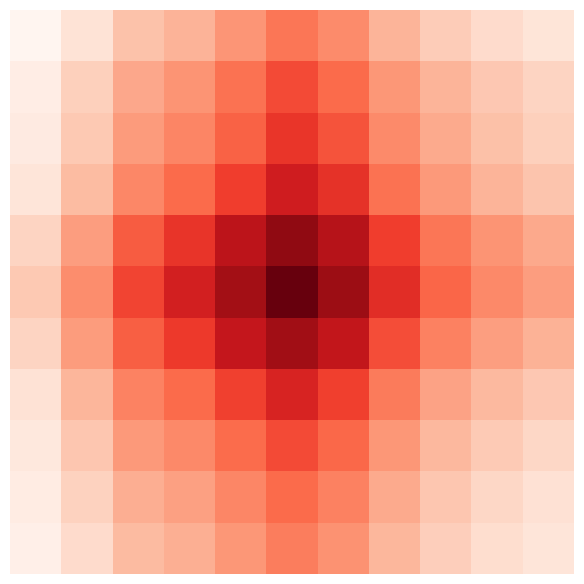

In [54]:
# ===================================================================
# Step 8.5: Plot the Local Region Around the Target Position
# ===================================================================

# Define parameters for a square centered on the target position
radius = 5

# Calculate the square boundaries
top_left_i = max(0, target_i - radius)
bottom_right_i = min(pred_hic_map.shape[0], target_i + radius + 1)
top_left_j = max(0, target_j - radius)
bottom_right_j = min(pred_hic_map.shape[1], target_j + radius + 1)

# Extract the local region
local_region = pred_hic_map[top_left_i:bottom_right_i, top_left_j:bottom_right_j]

# Plot the local-region heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    local_region,
    cmap='Reds',
    square=True,
    fmt='.3f',   # Numeric format
    cbar=False,
    xticklabels=False,  # Hide x-axis tick labels
    yticklabels=False   # Hide y-axis tick labels
)

# Calculate the target point's relative position in the local plot
relative_i = target_i - top_left_i
relative_j = target_j - top_left_j

# Remove axes
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()


In [55]:
# ===================================================================
# Step 9: Define a New Model Wrapper for the Target Position
# ===================================================================

def model_forward_for_pixel(seq_one_hot, omics_signals):
    """
    This wrapper receives sequence and omics data,
    but returns only the model prediction at the predefined (target_i, target_j) position.
    The return value must be a vector of shape (B,), where B is the batch size.
    """
    output = model(seq_one_hot, omics_signals)
    # Extract the value of the target pixel
    return output[:, target_i, target_j]

print("Created a new model wrapper for the target position (pixel-specific).")

Created a new model wrapper for the target position (pixel-specific).


In [56]:
# ===================================================================
# Step 10: Compute Attribution Scores for One Position
# ===================================================================

# --- 1. Initialize IG with the new wrapper ---
ig_pixel = IntegratedGradients(model_forward_for_pixel)

# --- 2. Prepare inputs and baselines ---
# The baseline represents an uninformative input and is typically an all-zero tensor.
# Create baselines for both sequence and omics data.
seq_baseline = torch.zeros_like(seq_input_batch)
omics_baseline = torch.zeros_like(omics_input_batch)

# --- 3. Compute attributions ---
# Captum allows multiple inputs to be passed as a tuple
# It returns a tuple containing attribution scores for each input
print("Calculating attribution scores for the target position... (this may take a while)")
attributions_tuple = ig_pixel.attribute(
    inputs=(seq_input_batch, omics_input_batch),
    baselines=(seq_baseline, omics_baseline),
    internal_batch_size=2 # Reduce this further if GPU memory is insufficient
)

# --- 4. Separate omics and sequence attribution results ---
seq_attributions, omics_attributions = attributions_tuple

# Move results from GPU to CPU and remove the batch dimension
seq_attr_np = seq_attributions.squeeze(0).cpu().detach().numpy()
omics_attr_np = omics_attributions.squeeze(0).cpu().detach().numpy()

print("\nAttribution calculation complete!")
print(f"  - Sequence attribution shape: {seq_attr_np.shape}")
print(f"  - Omics attribution shape:   {omics_attr_np.shape}")

Calculating attribution scores for the target position... (this may take a while)

Attribution calculation complete!
  - Sequence attribution shape: (4, 1024000)
  - Omics attribution shape:   (4, 512)


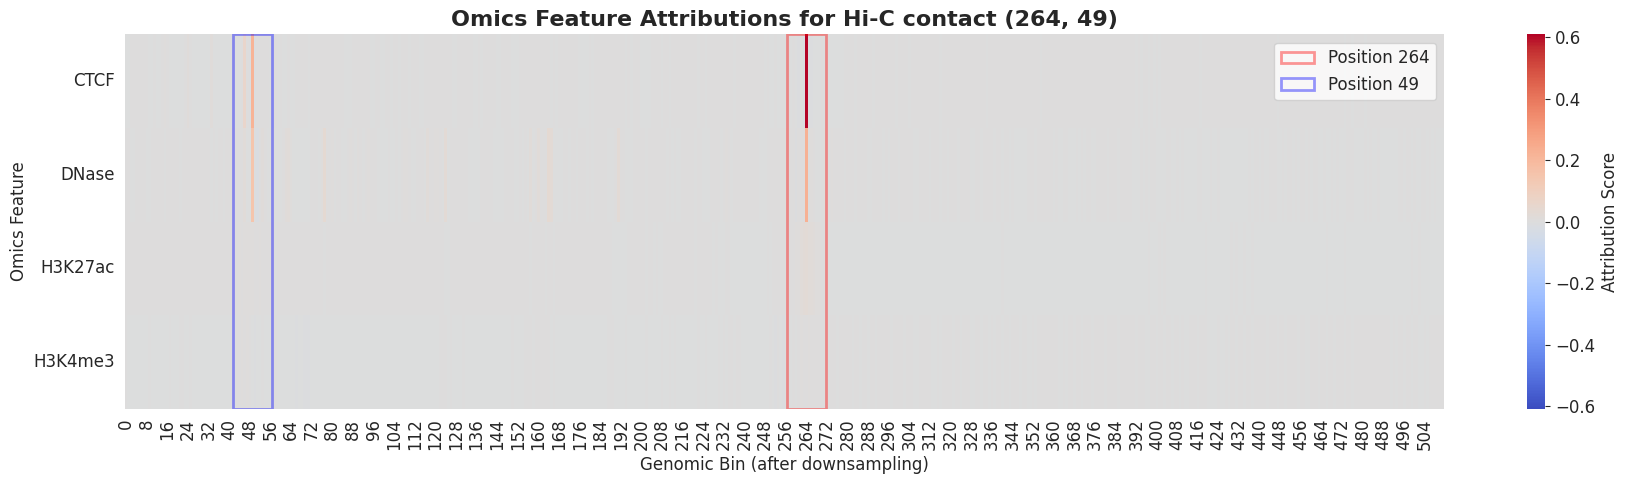

In [60]:
# ===================================================================
# Step 11.1: Visualize Positional Importance of Omics Features
# ===================================================================

import matplotlib.patches as patches

# Find the maximum absolute attribution score for a symmetric color scale
max_abs_val = np.max(np.abs(omics_attr_np))

plt.figure(figsize=(18, 5))
ax = plt.gca()

# Plot the heatmap
sns.heatmap(
    omics_attr_np,
    cmap='coolwarm',  # Use a diverging palette: blue for negative and red for positive contributions
    cbar_kws={'label': 'Attribution Score'},
    yticklabels=config.omics_feature_names,
    vmin=-max_abs_val,  # Symmetric color scale
    vmax=max_abs_val,
    ax=ax
)

# Get the y-axis range (the number of omics features)
n_features = omics_attr_np.shape[0]
w = 15
# Add a vertical rectangle at target_i
rect_i = patches.Rectangle(
    (target_i-w//2, 0),  # Rectangle's lower-left position
    w,  # Width (one bin)
    n_features,  # Height (covers all features)
    linewidth=2,  # Border width
    edgecolor='red',  # Border color
    facecolor='none',  # Transparent fill
    alpha=0.4,  # Border opacity
    label=f'Position {target_i}'
)
ax.add_patch(rect_i)

# Add a vertical rectangle at target_j
rect_j = patches.Rectangle(
    (target_j-w//2, 0),  # Rectangle's lower-left position
    w,  # Width (one bin)
    n_features,  # Height (covers all features)
    linewidth=2,  # Border width
    edgecolor='blue',  # Border color
    facecolor='none',  # Transparent fill
    alpha=0.4,  # Border opacity
    label=f'Position {target_j}'
)
ax.add_patch(rect_j)

# Add the title and labels
plt.title(f'Omics Feature Attributions for Hi-C contact ({target_i}, {target_j})', 
          fontsize=16, fontweight='bold')
plt.xlabel('Genomic Bin (after downsampling)', fontsize=12)
plt.ylabel('Omics Feature', fontsize=12)
plt.yticks(rotation=0)

# Add the legend
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

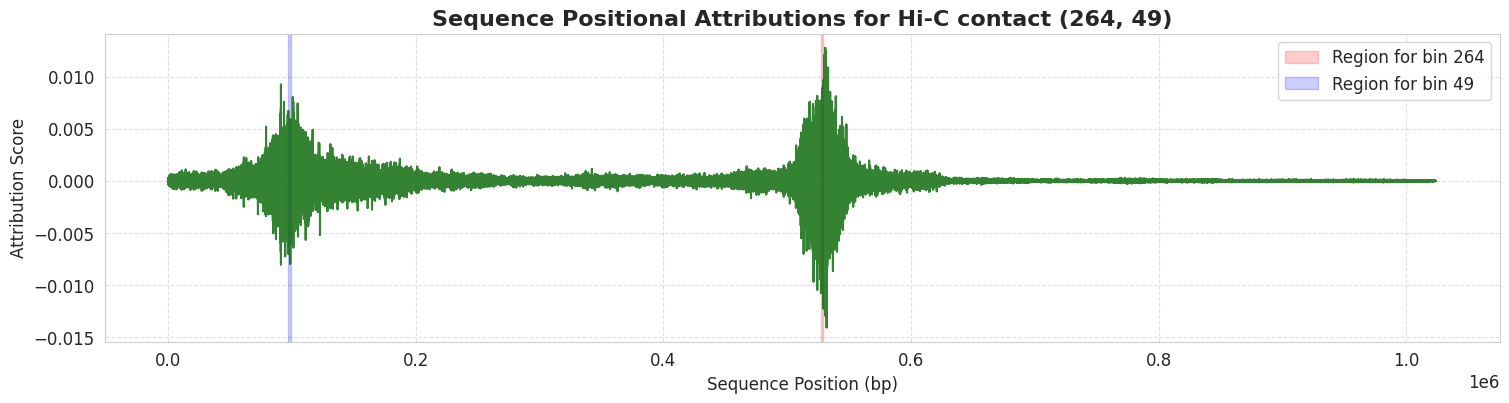

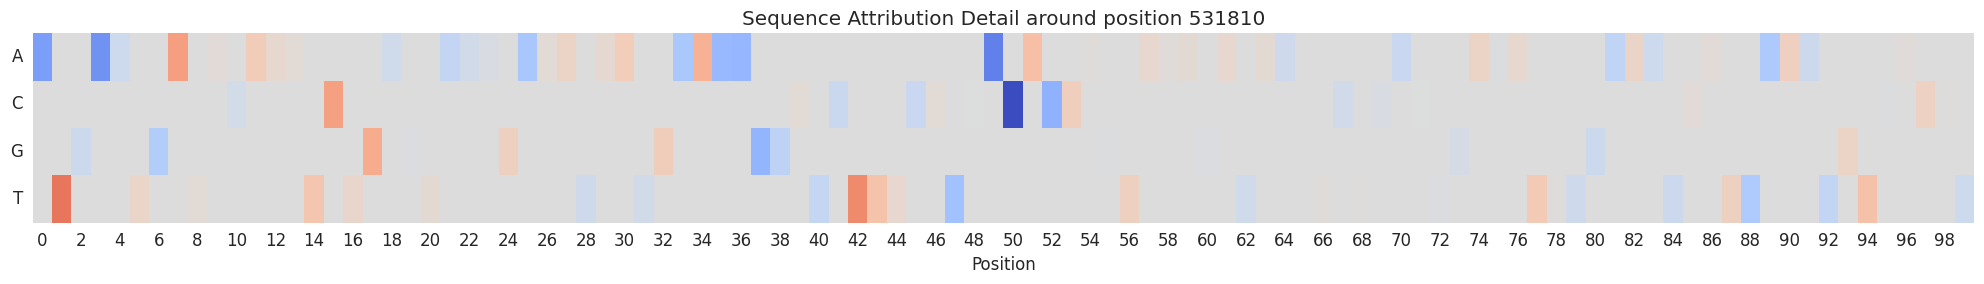

In [61]:
# ===================================================================
# Step 11.2: Visualize Positional Importance of Sequence Features
# ===================================================================
# --- 1. Calculate total contribution at each position ---
# Multiply attribution scores by the one-hot encoding to retain contributions from observed bases only
# Sum across the base dimension to obtain one importance score per position
seq_input_np = seq_input_batch.squeeze(0).cpu().numpy()
positional_seq_attr = (seq_attr_np * seq_input_np).sum(axis=0)

# --- 2. Plot the positional contribution curve ---
plt.figure(figsize=(18, 4))
plt.plot(positional_seq_attr, color='darkgreen', alpha=0.8)
# Mark regions associated with the Hi-C positions on the plot
# The (target_i, target_j) coordinates are downsampled and must be mapped to the original sequence length
# The downsampling factor is 5*5*5*4*4 = 2000
original_pos_i = target_i * 2000
original_pos_j = target_j * 2000
plt.axvspan(original_pos_i - 1000, original_pos_i + 1000, color='red', alpha=0.2, label=f'Region for bin {target_i}')
plt.axvspan(original_pos_j - 1000, original_pos_j + 1000, color='blue', alpha=0.2, label=f'Region for bin {target_j}')

plt.title(f'Sequence Positional Attributions for Hi-C contact ({target_i}, {target_j})', fontsize=16, fontweight='bold')
plt.xlabel('Sequence Position (bp)', fontsize=12)
plt.ylabel('Attribution Score', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 3. (Optional) Create a Sequence Logo-like Visualization ---
# Use a logo-like plot for a finer-grained view of base-level contributions
# Visualize only a short region with the strongest contributions
# For example, locate the region with the highest contribution
peak_pos = np.argmax(np.abs(positional_seq_attr))
start = max(0, peak_pos - 50)
end = min(len(positional_seq_attr), peak_pos + 50)

# Get attributions and sequence for this region
region_attr = seq_attr_np[:, start:end]
region_seq = seq_input_np[:, start:end]

# Set attributions for absent bases to zero
region_attr_on_bases = region_attr * region_seq

df_seq = pd.DataFrame(region_attr_on_bases.T, columns=['A', 'C', 'G', 'T'])

def plot_seq_logo(df, ax, title):
    max_abs_val = df.abs().max().max()
    sns.heatmap(df.T, cmap='coolwarm', vmin=-max_abs_val, vmax=max_abs_val, ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_xlabel('Position')
    ax.set_yticklabels(df.columns, rotation=0)

fig, ax = plt.subplots(1, 1, figsize=(20, 3))
plot_seq_logo(df_seq, ax, f"Sequence Attribution Detail around position {peak_pos}")
fig.tight_layout()
plt.show()

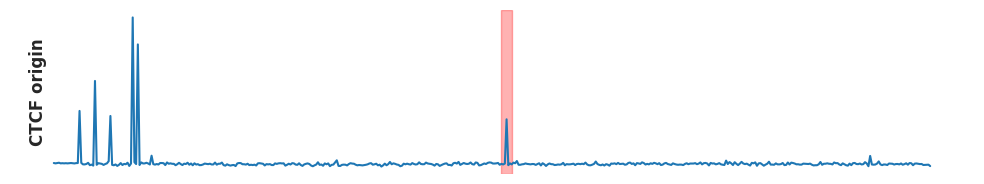

In [39]:
plt.figure(figsize=(10, 2))
plt.plot(omics_input_batch[0,0].detach().cpu().numpy())
plt.axvspan(xmin=264-3, xmax=264+3, color='red', alpha=0.3)
plt.text(0.02, 0.5, 'CTCF origin', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='center', rotation=90)
plt.axis('off')
plt.grid(False)
plt.tight_layout()

Sample dimensions:
  - Sequence: torch.Size([1, 4, 1024000])
  - Omics:    torch.Size([1, 4, 512])


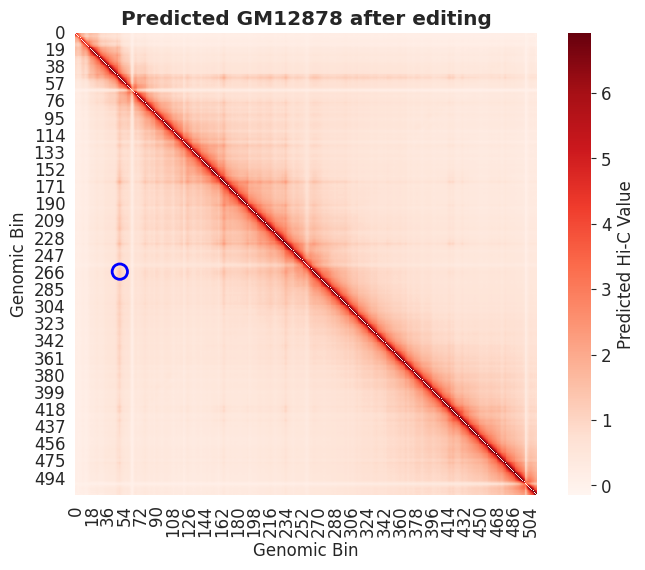


Selected target position (i, j) = (264, 49) for interpretability analysis.
Prediction at this position: 1.3873


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle

# ===================================================================
# Step 8: Select a Sample and Hi-C Contact for Analysis
# ===================================================================

# --- 1. Select a sample from the test set ---
# Use the first test_dataset sample as an example
seq_input, omics_input, true_hic, name = test_dataset[2]

# Create a batch (batch_size=1) and move it to the device
seq_input_batch = seq_input.unsqueeze(0).to(device)
omics_input_batch = omics_input.unsqueeze(0).to(device)

# --- Edit: set positions 260 through 270 of omics_input_batch[0, 0] to zero ---
omics_input_batch[0, 0, 260:271] = 0

print(f"Sample dimensions:")
print(f"  - Sequence: {seq_input_batch.shape}")
print(f"  - Omics:    {omics_input_batch.shape}")

# --- 2. Run inference and visualize the sample ---
with torch.no_grad():
    pred_hic_map = model(seq_input_batch, omics_input_batch).squeeze(0).cpu().numpy()

# --- 3. Manually select a position (i, j) to explain ---
target_i, target_j = 264, 49
# Plot the predicted map
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    pred_hic_map,
    cmap='Reds',
    cbar_kws={'label': 'Predicted Hi-C Value'},
    square=True
)
plt.title(f'Predicted GM12878 after editing', fontweight='bold')
plt.xlabel('Genomic Bin')
plt.ylabel('Genomic Bin')

# === ✅ Mark the target point with a circle ===
circle = Circle(
    (target_j + 0.5, target_i + 0.5),  # Circle center (add 0.5 to center it in the cell)
    radius=8.5,                        # Radius; adjust as needed
    fill=False,                        # No fill
    edgecolor='blue',                # Circle color
    linewidth=2.0                      # Circle line width
)
ax.add_patch(circle)

plt.show()

print(f"\nSelected target position (i, j) = ({target_i}, {target_j}) for interpretability analysis.")
print(f"Prediction at this position: {pred_hic_map[target_i, target_j]:.4f}")

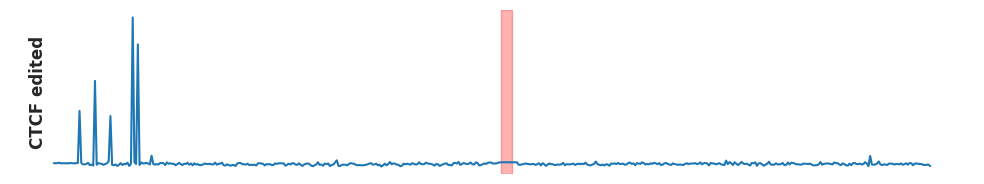

In [66]:
plt.figure(figsize=(10, 2))
plt.plot(omics_input_batch[0,0].detach().cpu().numpy())
plt.axvspan(xmin=264-3, xmax=264+3, color='red', alpha=0.3)
plt.text(0.02, 0.5, 'CTCF edited', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='center', rotation=90)
plt.axis('off')
plt.grid(False)
plt.tight_layout()

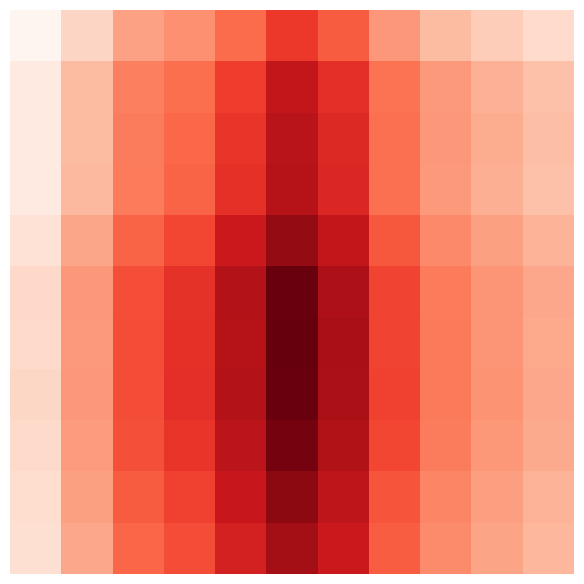

In [ ]:
# ===================================================================
# Step 8.5: Plot the Local Region Around the Target Position
# ===================================================================

# Define parameters for a square centered on the target position
radius = 5

# Calculate the square boundaries
top_left_i = max(0, target_i - radius)
bottom_right_i = min(pred_hic_map.shape[0], target_i + radius + 1)
top_left_j = max(0, target_j - radius)
bottom_right_j = min(pred_hic_map.shape[1], target_j + radius + 1)

# Extract the local region
local_region = pred_hic_map[top_left_i:bottom_right_i, top_left_j:bottom_right_j]

# Plot the local-region heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    local_region,
    cmap='Reds',
    square=True,
    fmt='.3f',   # Numeric format
    cbar=False,
    xticklabels=False,  # Hide x-axis tick labels
    yticklabels=False   # Hide y-axis tick labels
)

# Calculate the target point's relative position in the local plot
relative_i = target_i - top_left_i
relative_j = target_j - top_left_j

# Remove axes
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()
